# 0. Import

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("/home/ubuntu/dev/projects/tcc/tcc_mba/hydrometeorological-anomalies-prophet/dados/processed/serie_prophet_rmr_2020_2025.csv")

In [19]:
df.head()

,ds,y
0,2020-01-01,20.481977
1,2020-01-02,16.079409
2,2020-01-03,24.879173
3,2020-01-04,4.280869
4,2020-01-05,0.759733


In [20]:
df['y'].unique()

array([20.481977 , 16.079409 , 24.879173 , ..., 26.088247 ,  2.0832396,
       28.526123 ], shape=(2192,))

In [21]:
df.shape

(2192, 2)

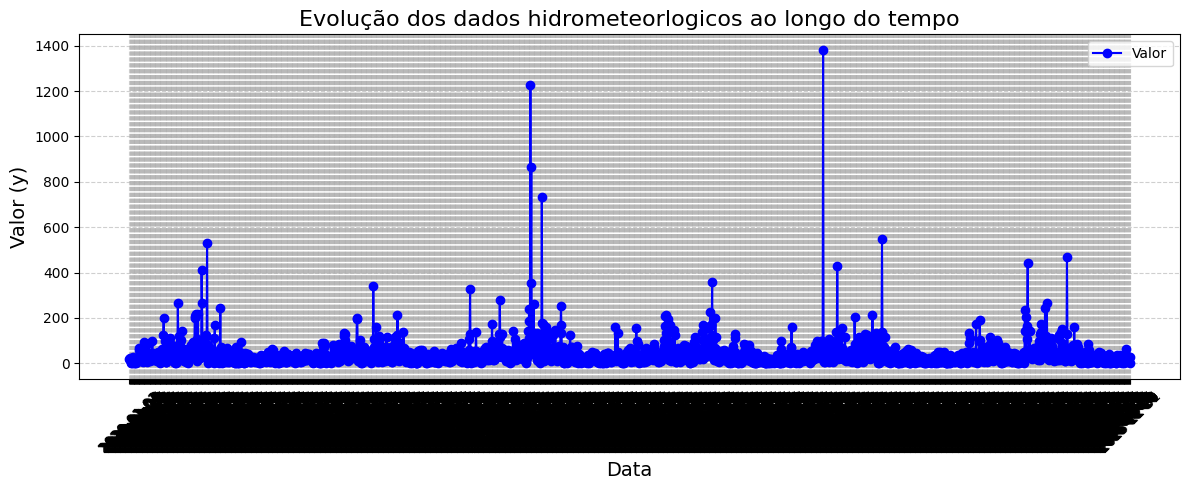

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], marker='o', linestyle='-', color='b', label='Valor')
plt.title('Evolução dos dados hidrometeorlogicos ao longo do tempo', fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Valor (y)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [23]:
df.head(1)

,ds,y
0,2020-01-01,20.481977


In [24]:
df['ds'] = pd.to_datetime(df['ds'])

df['ano'] = df['ds'].dt.year
df['mes'] = df['ds'].dt.month
1
df_mensal = df.groupby(['ano', 'mes'])['y'].mean().reset_index()

df_mensal['data'] = pd.to_datetime(
    df_mensal['ano'].astype(str) + '-' + 
    df_mensal['mes'].astype(str) + '-01'
)

df_mensal

,ano,mes,y,data
0,2020,1,17.375315,2020-01-01
1,2020,2,34.276275,2020-02-01
2,2020,3,42.015403,2020-03-01
3,2020,4,52.617295,2020-04-01
4,2020,5,64.181526,2020-05-01
...,...,...,...,...
67,2025,8,64.050208,2025-08-01
68,2025,9,30.935173,2025-09-01
69,2025,10,25.075992,2025-10-01
70,2025,11,11.557993,2025-11-01


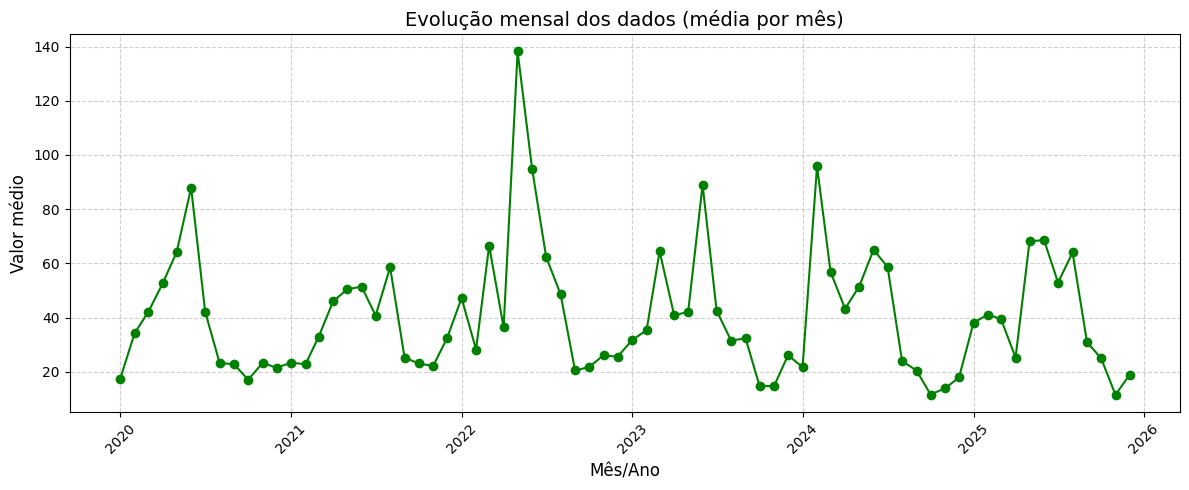

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(df_mensal['data'], df_mensal['y'], marker='o', linestyle='-', color='green')
plt.title('Evolução mensal dos dados (média por mês)', fontsize=14)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Valor médio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
df.shape

(2192, 4)

In [27]:
df_mensal.shape

(72, 4)

In [28]:
df_mensal

,ano,mes,y,data
0,2020,1,17.375315,2020-01-01
1,2020,2,34.276275,2020-02-01
2,2020,3,42.015403,2020-03-01
3,2020,4,52.617295,2020-04-01
4,2020,5,64.181526,2020-05-01
...,...,...,...,...
67,2025,8,64.050208,2025-08-01
68,2025,9,30.935173,2025-09-01
69,2025,10,25.075992,2025-10-01
70,2025,11,11.557993,2025-11-01


In [29]:
contagem_meses = df.groupby('ano')['mes'].nunique().reset_index()
contagem_meses.columns = ['ano', 'meses_distintos']

contagem_meses['ano_completo'] = contagem_meses['meses_distintos'] == 12

print(contagem_meses)

    ano  meses_distintos  ano_completo
0  2020               12          True
1  2021               12          True
2  2022               12          True
3  2023               12          True
4  2024               12          True
5  2025               12          True


In [30]:
todos_completos = contagem_meses['ano_completo'].all()

if todos_completos:
    print('todos os anos possuem 12 meses')
else:
    print("alguns anos estão incompletos")
    print(contagem_meses[~contagem_meses['ano_completo']])

todos os anos possuem 12 meses


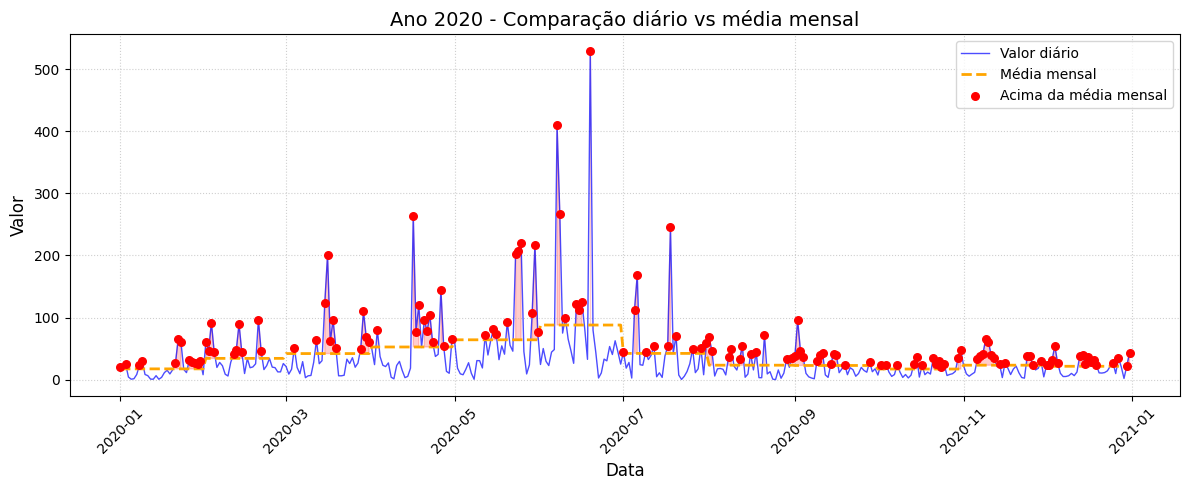

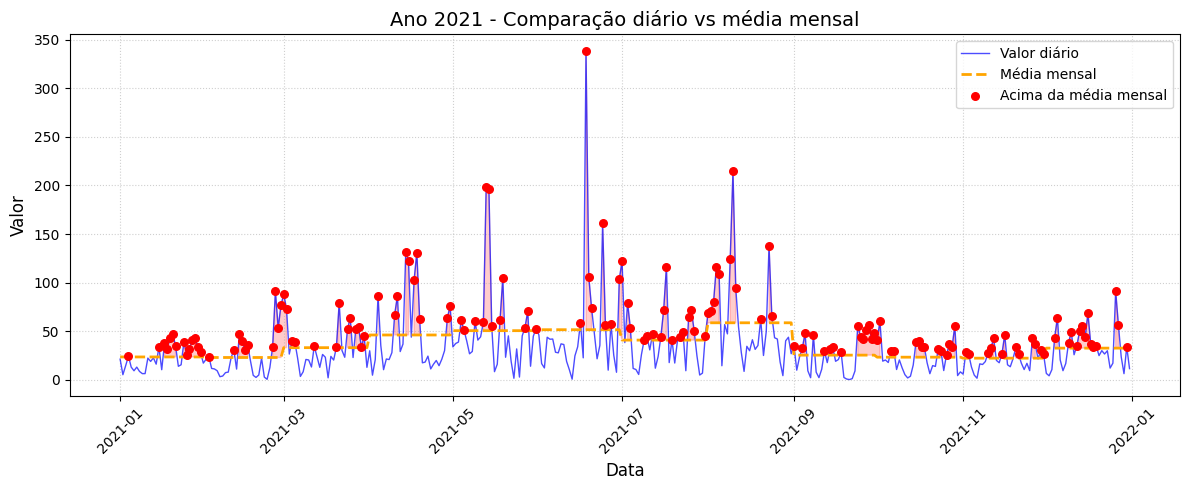

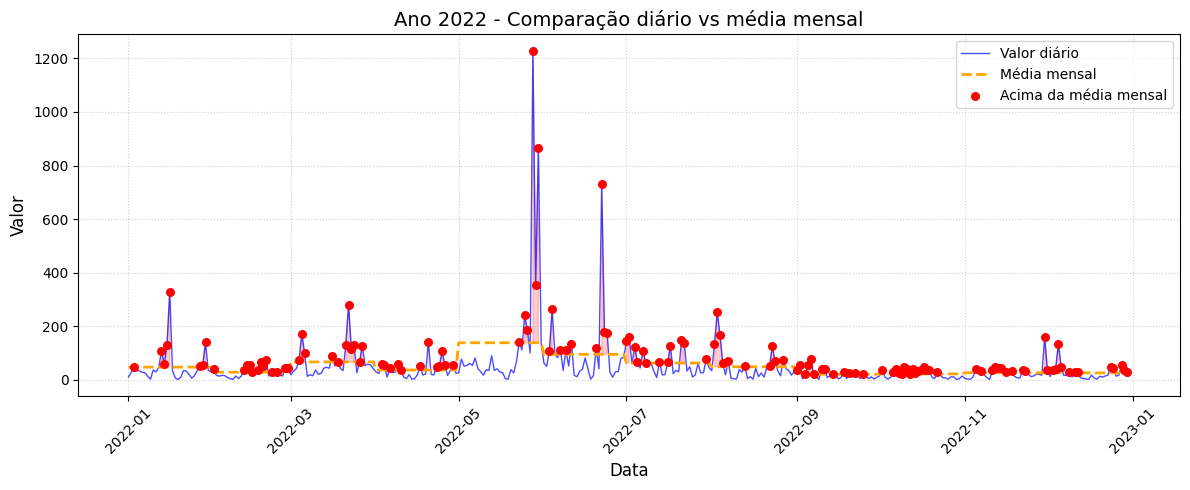

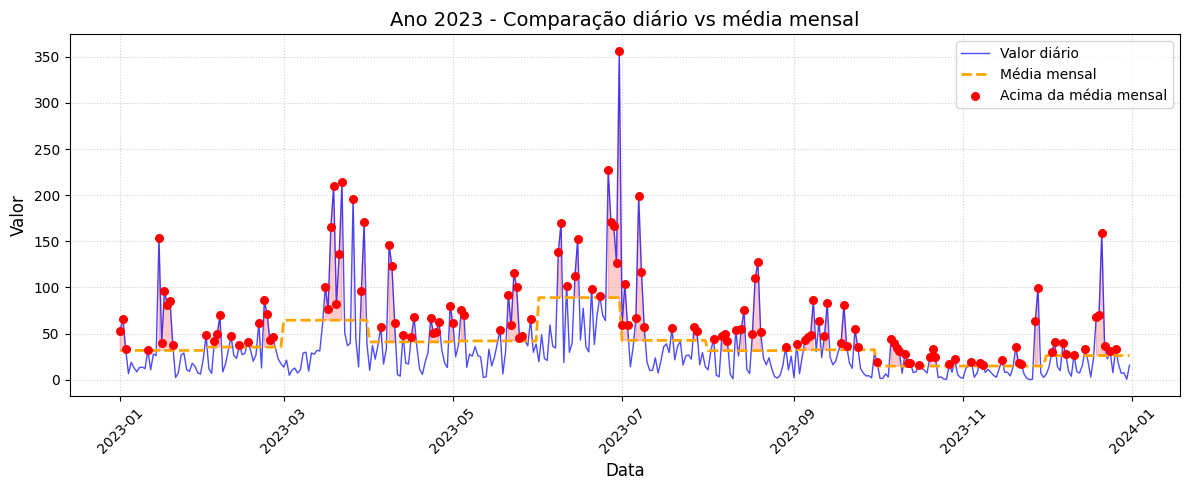

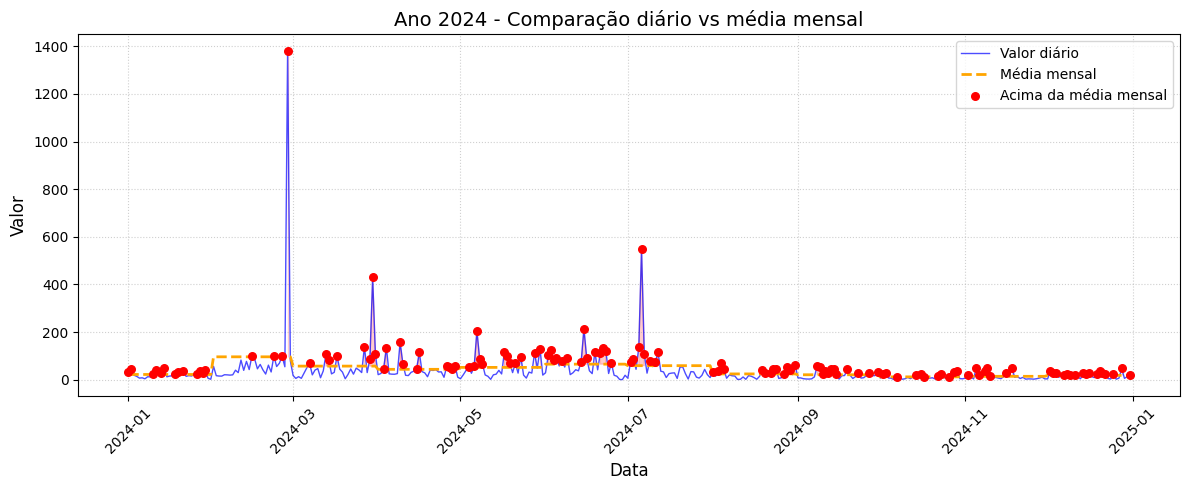

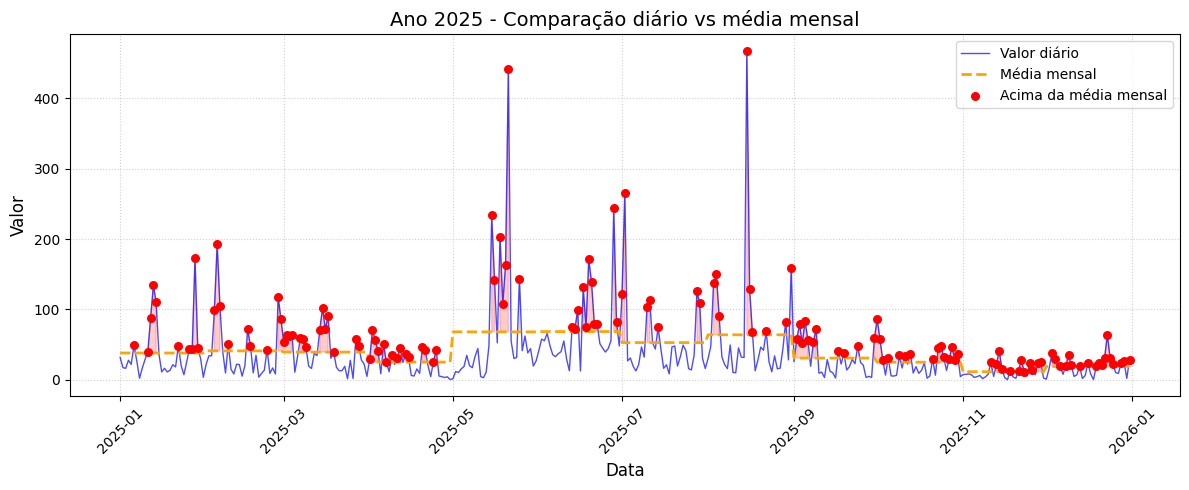

In [31]:
# 1. Preparar o df diário com a média mensal associada
df['ano_mes'] = df['ds'].dt.strftime('%Y-%m')
df_mensal['ano_mes'] = df_mensal['ano'].astype(str) + '-' + df_mensal['mes'].astype(str).str.zfill(2)
df['media_mensal'] = df['ano_mes'].map(df_mensal.set_index('ano_mes')['y'])
df['acima_media'] = df['y'] > df['media_mensal']

# 2. Listar os anos presentes nos dados
anos = sorted(df['ds'].dt.year.unique())

# 3. Para cada ano, criar um gráfico separado
for ano in anos:
    # Filtrar dados do ano
    df_ano = df[df['ds'].dt.year == ano].copy()
    
    if df_ano.empty:
        continue
    
    # Criar figura e eixo
    plt.figure(figsize=(12, 5))
    
    # Linha diária
    plt.plot(df_ano['ds'], df_ano['y'], color='blue', linewidth=1, alpha=0.7, label='Valor diário')
    
    # Linha da média mensal (constante por mês)
    plt.plot(df_ano['ds'], df_ano['media_mensal'], color='orange', linewidth=2, linestyle='--', label='Média mensal')
    
    # Pontos onde diário > média mensal
    pontos = df_ano[df_ano['acima_media']]
    if not pontos.empty:
        plt.scatter(pontos['ds'], pontos['y'], color='red', s=30, zorder=5, label='Acima da média mensal')
    
    # Preenchimento opcional
    plt.fill_between(df_ano['ds'], df_ano['y'], df_ano['media_mensal'],
                     where=df_ano['y'] > df_ano['media_mensal'],
                     color='red', alpha=0.2)
    
    # Título e labels
    plt.title(f'Ano {ano} - Comparação diário vs média mensal', fontsize=14)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Valor', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Mostrar (ou salvar) o gráfico
    plt.show()
    
    # Opcional: salvar cada gráfico como arquivo
    # plt.savefig(f'grafico_{ano}.png', dpi=150, bbox_inches='tight')
    # plt.close()